#### Imports

In [37]:
from ultralytics import YOLO
import shutil
import requests
from io import BytesIO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import math
import os

#### Functions

In [ ]:
# ------------------------------------
#         MapTiler API Download
# ------------------------------------

def deg2num(lat, lon, zoom):
    """
    Calculate XYZ-Coords from Lat/Lon
    """
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.log(math.tan(lat_rad) +
                (1 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return x, y


def fetch_tile(map_id, zoom, x, y, api_key):
    """
    Loads single MapTiler Tile
    """
    url = f"https://api.maptiler.com/maps/{map_id}/256/{zoom}/{x}/{y}.png?key={api_key}"
    r = requests.get(url)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))


def build_map(lat, lon, zoom, tiles_radius, api_key, map_id="satellite"):
    """
    Creates Satellite-Image from multiple tiles around center point
    """
    center_x, center_y = deg2num(lat, lon, zoom)

    size = 256 * (tiles_radius * 2 + 1)
    canvas = Image.new("RGB", (size, size))

    for dx in range(-tiles_radius, tiles_radius + 1):
        for dy in range(-tiles_radius, tiles_radius + 1):
            x = center_x + dx
            y = center_y + dy
            tile = fetch_tile(map_id, zoom, x, y, api_key)
            px = (dx + tiles_radius) * 256
            py = (dy + tiles_radius) * 256
            canvas.paste(tile, (px, py))

    return canvas





# ------------------------------------
#         YOLO Prediction
# ------------------------------------

def predict_intersection(save_dir, image_path, model_path="yolov11n-seg.pt"):    

    # load model
    model = YOLO(model_path)

    # segment image (prediction)
    results = model.predict(
        source=image_path,
        imgsz=512,     
        device=0,      # GPU
        conf=0.2,      # Confidence
        save=True,
        project=f"{save_dir}",
        save_txt=True,
    )

    # get resulting image
    result_img = results[0].plot()  # returns rgb image of np.array from result object

    # visualize
    plt.figure(figsize=(8,8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.show()

    return results





# ------------------------------------
#          Image Center Point
# ------------------------------------

def center_point_visualize(image_path, label_path, save_result=True):

    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    width, height = img.size
    with open(label_path, "r") as f:
        line = f.readline().strip()
    

    parts = line.split()
    coords = [float(x) for x in parts[1:]]  # ignore class_id 
    polygon = np.array(coords).reshape(-1, 2)


    # Get center point
    centerPoint = polygon.mean(axis=0)
    cx, cy = int(centerPoint[0]*width), int(centerPoint[1]*height)


    # Draw center point in Segmentation
    r = 8
    draw.ellipse((cx-r, cy-r, cx+r, cy+r), fill="red")

    # Save Image as Result
    if save_result:
        folder = os.path.dirname(label_path)
        basename = os.path.splitext(os.path.basename(image_path))[0]
        output_path = f"{folder}/{basename}_centerPoint.png"
        img.save(output_path)

   
   
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    return centerPoint




# ------------------------------------
#          Geo Coordinates
# ------------------------------------

def get_meters_per_pixel(lat, zoom):
    earth_circumference = 40075017  # in meters
    lat_rad = math.radians(lat)
    meters_per_pixel = (earth_circumference * math.cos(lat_rad)) / (256 * 2**zoom)

    return meters_per_pixel


def yolo_to_geo(cp_x, cp_y, img_width, img_height, lat_center, lon_center, meters_per_pixel):

    # Position of Center Point Pixel
    x_pixel = cp_x * img_width
    y_pixel = cp_y * img_height

    # Position of Image center Pixel
    center_x = img_width / 2
    center_y = img_height / 2

    # Difference in px
    dx_pixels = x_pixel - center_x
    dy_pixels = center_y - y_pixel

    # Difference in m
    dx_m = dx_pixels * meters_per_pixel
    dy_m = dy_pixels * meters_per_pixel

    # Calculate lat/lon from Difference from image center
    lat = lat_center + (dy_m / 111320)
    lon = lon_center + (dx_m / (111320 * math.cos(math.radians(lat_center))))

    return lat, lon

## Get Image from MapTiler API

In [39]:
api_key = "qR5z0FXl7vgm9kk146HC"

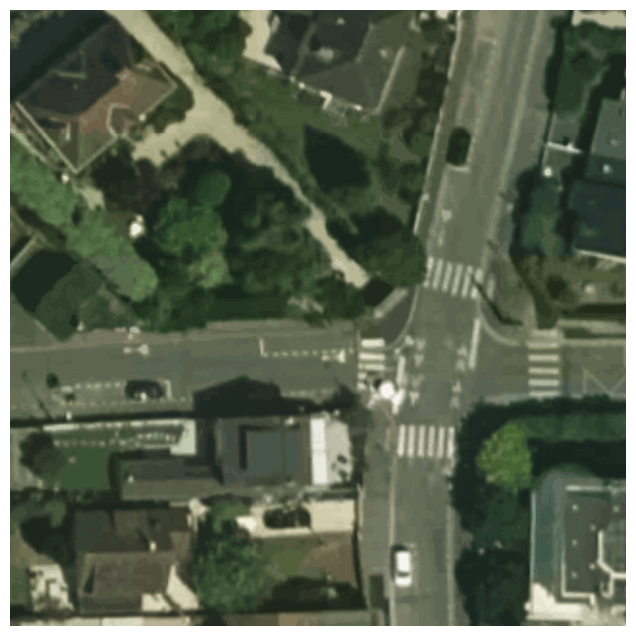

In [ ]:
if __name__ == "__main__":

    lat, lon = 49.182206, -0.359821         # good example YOLO_Test1
    # lat, lon = 49.186570, -0.355924       # YOLO_Test2
    # lat, lon = 49.186597, -0.355784       # YOLO_Test21; schlechtere conf obwohl weiter in kreuzungsmitte
    # lat, lon = 49.186358, -0.372618       # meh  YOLO_Test3
    # lat, lon = 49.183615, -0.354067       # okayish test_UP+RIGHT
    lat, lon = 49.175246, -0.383079         # satimg_1
    

    # Name of Satellite Image
    img_name = "satimg_1"



    # number of tiles around center-coords
    tiles_radius = 2
    zoom = 21       # Std = 21

    map_img = build_map(lat, lon, zoom, tiles_radius, api_key)
    
    img_input_fp = "dataset/input_images"
    os.makedirs(img_input_fp, exist_ok=True)
    map_img.save(f"{img_input_fp}/{img_name}.png")
    
    plt.figure(figsize=(8,8))
    plt.imshow(map_img)
    plt.axis('off')
    plt.show()

## Segmentation


image 1/1 c:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\input_images\satimg_1.png: 512x512 1 intersection, 16.1ms
Speed: 2.8ms preprocess, 16.1ms inference, 5.5ms postprocess per image at shape (1, 3, 512, 512)
Results saved to C:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\predictions\satimg_1\predict
1 label saved to C:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\predictions\satimg_1\predict\labels


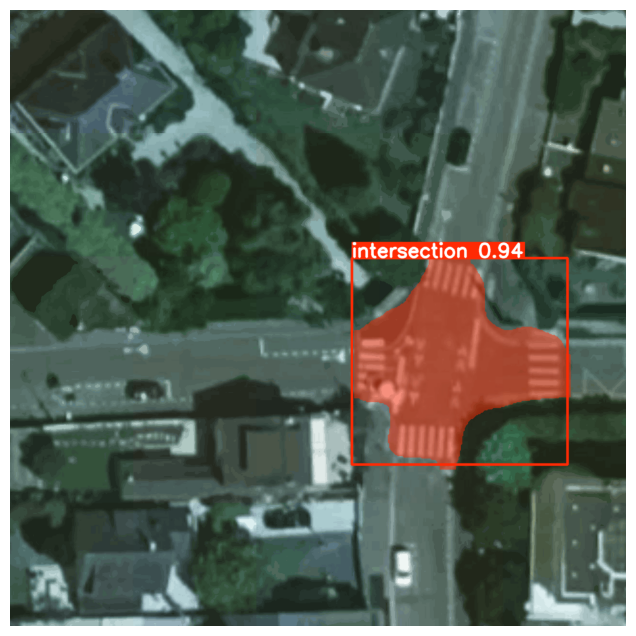

In [41]:
os.makedirs("dataset/predictions", exist_ok=True)       # Create/Check for predictionsfolder


save_dir = f"dataset/predictions/{img_name}"    # save in predictions-folder for each image processed
os.makedirs(save_dir, exist_ok=True)
if save_dir:
    shutil.rmtree(save_dir)     # deletes previous results


# Segmentation/Prediction
results = predict_intersection(
    save_dir=save_dir,
    image_path= f"{img_input_fp}/{img_name}.png",
    model_path="dataset/runs/segment/train/weights/best.pt",    # Path to YOLO-model
)

## Get Center Point

In [42]:
if not save_dir:
    print(f"No Predictions for image {img_name}")

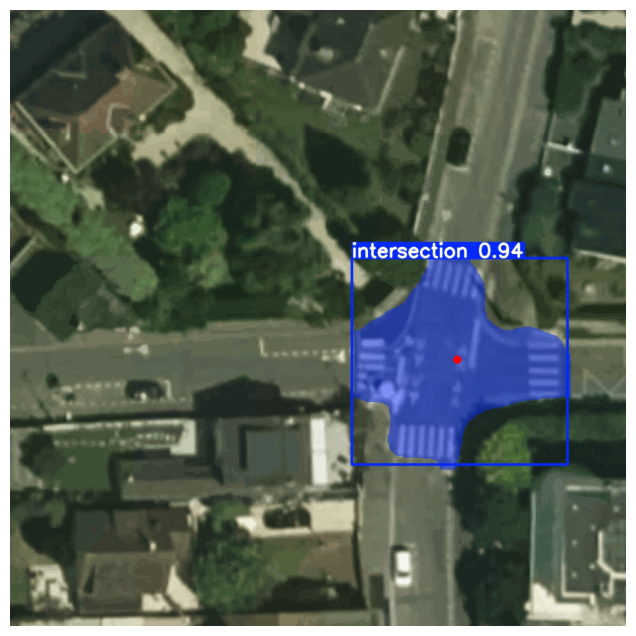

Center Point of Segmentation (pixel in YOLO format): [0.7264587 0.5677272]


In [43]:
# Prediciton Image and Labels
image_path = f"{save_dir}/predict/{img_name}.jpg"
label_path = f"{save_dir}/predict/labels/{img_name}.txt"

# Get and Visualize center point
center_point = center_point_visualize(image_path, label_path)

print("Center Point of Segmentation (pixel in YOLO format):",center_point)

## Get Geo-Coordinates of Center point

In [44]:
# Get Center Point
cx, cy = center_point[0], center_point[1]
# cx, cy = 0.5, 0.5       # Test with image center


mpp = get_meters_per_pixel(lat, zoom)
print("Meters per Pixel:", mpp)


# Get geo Coords of Center Point
cp_lat, cp_lon = yolo_to_geo(cx, cy, 1280, 1280, lat, lon, mpp)

print(cp_lat, cp_lon)
print("Center Point lat:", cp_lat, "Center Point lon:", cp_lon)

Meters per Pixel: 0.048799339593698275
49.17520799735493 -0.38288462982583926
Center Point lat: 49.17520799735493 Center Point lon: -0.38288462982583926


##